# G_2 — Figure 2: durations and attrition

**Input:** `Results/08.csv`
**Output:** Figures 2b and 2c

Figure 2b shows the empirical distribution of transition durations by phase;
the multimodal peaks reflect the biennial reporting cadence. Figure 2c shows
cumulative expected durations and phase-specific success probabilities from the
Markov chain.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns
import numpy as np
import matplotlib as mpl


In [2]:
file_path = "Results/08.csv" 
df = pd.read_csv(file_path)

### Colors

'1 -> 2': 'Consideration',         '#8EADC1'

'2 -> 3': 'Planning',              '#6089A4'

'3 -> 4': 'Design & \nPermitting', '#396481'

'4 -> 5': 'Construction',          '#1B435E'

'5':      'Commissioned',          '#08306b', 

'6':      'Cancelled':             '#67000d', 

In [3]:
df['Duration'] = df['Tstop'] - df['Tstart']
df['Transition'] = df['from'].astype(str) + " -> " + df['to'].astype(str)

df = df.sort_values(by=['from', 'to'])

In [4]:
all_transitions_stats = df.groupby('Transition')['Duration'].agg(['mean', 'count'])
all_transitions_stats = all_transitions_stats.sort_index()
all_transitions_stats.columns = ['Mean Duration (Years)', 'Sample Size (N)']
success_mask = all_transitions_stats.index.isin(['1 -> 2', '2 -> 3', '3 -> 4', '4 -> 5'])
cancel_mask = all_transitions_stats.index.str.endswith('-> 6')

In [5]:
target_success = ['1 -> 2', '2 -> 3', '3 -> 4', '4 -> 5']
success_means = df.groupby('Transition')['Duration'].mean().reindex(target_success)

cumulative_success = success_means.cumsum()
success_counts = df.groupby('Transition').size().reindex(target_success).fillna(0).astype(int)

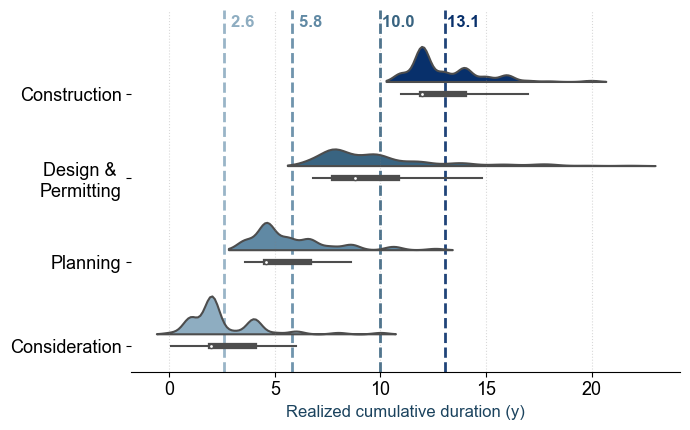

In [6]:
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['ps.fonttype'] = 42

target_transitions = ['1 -> 2', '2 -> 3', '3 -> 4', '4 -> 5']
phase_mapping = {
    '1 -> 2': 'Consideration',
    '2 -> 3': 'Planning',
    '3 -> 4': 'Design & \nPermitting',
    '4 -> 5': 'Construction'
}

df_subset = df[df['Transition'].isin(target_transitions)].copy()
df_shifted = df_subset.copy()
n_cat = len(target_transitions)

cumulative_shift = 0
start_points = {}
means = {}

for trans in target_transitions:
    start_points[trans] = cumulative_shift
    mask = df_shifted['Transition'] == trans
    df_shifted.loc[mask, 'Duration'] += cumulative_shift
    mean_duration = df_subset[df_subset['Transition'] == trans]['Duration'].mean()
    means[trans] = mean_duration
    cumulative_shift += mean_duration

df_shifted['Transition'] = df_shifted['Transition'].map(phase_mapping)

order_labels = [phase_mapping[t] for t in target_transitions]
colors = ['#8EADC1', '#6089A4', '#396481', '#08306B']

order_labels_reversed = order_labels[::-1]
colors_reversed = colors[::-1]

f, ax = plt.subplots(figsize=(7, 1.1 * n_cat))

pt.half_violinplot(
    data=df_shifted,
    x='Duration',
    y='Transition',
    order=order_labels_reversed,
    palette=colors_reversed,
    bw=0.2,
    ax=ax,
    orient='h',
    width=0.9
)

for i, trans in enumerate(target_transitions):
    end_point = start_points[trans] + means[trans]
    current_color = colors[i]
    
    ax.axvline(x=end_point, color=current_color, linestyle='--', linewidth=2, alpha=0.9, zorder=0)
    ax.text(end_point, -0.8, f'        {end_point:.1f}', 
            color=current_color, fontsize=12, ha='center', fontweight='bold')

plt.xlabel("Realized cumulative duration (y)", color='#1B435E', fontsize=12)

plt.grid(axis='x', linestyle=':', alpha=0.3, color='gray')
sns.despine(left=True)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

ax.margins(y=0.2)
ax.set_ylim(n_cat - 0.7, -1) 

plt.tight_layout()
plt.savefig("Images/Raincloud_Duration.png", dpi=300, bbox_inches='tight')
plt.show()

# Mean First Passage Time (MFPT)

In [7]:
df['From_State'] = df['Transition'].astype(str).str.split(' -> ').str[0]
df['From_State'] = pd.to_numeric(df['From_State'], errors='coerce')

total_exposure = df.groupby('From_State')['Duration'].sum()

transient_states = [1, 2, 3, 4]
absorbing_states = [5, 6]
n_transient = len(transient_states)

count_matrix = pd.DataFrame(0.0, index=transient_states, columns=transient_states + absorbing_states)

stats_df = df.groupby('Transition')['Duration'].agg(['count']).reset_index()
stats_df[['From', 'To']] = stats_df['Transition'].astype(str).str.split(' -> ', expand=True)

for _, row in stats_df.iterrows():
    if pd.notna(row['To']) and row['To'].strip().isdigit():
        i, j = int(row['From']), int(row['To'])
        if i in transient_states and j in (transient_states + absorbing_states):
            count_matrix.at[i, j] = row['count']

total_transitions_out = count_matrix.sum(axis=1)
P = count_matrix.div(total_transitions_out, axis=0)

W = np.zeros(n_transient)
for idx, state in enumerate(transient_states):
    exposure = total_exposure.get(state, 0)
    transitions = total_transitions_out.loc[state]
    
    if transitions > 0:
        W[idx] = exposure / transitions
    else:
        W[idx] = 0

Q = P.loc[transient_states, transient_states].values
R = P.loc[transient_states, absorbing_states].values

I = np.eye(n_transient)
F = np.linalg.inv(I - Q)

B = np.dot(F, R)
prob_reach_5 = B[:, 0]

Q_star = np.zeros_like(Q)
for i in range(n_transient):
    for j in range(n_transient):
        if prob_reach_5[i] > 0:
            Q_star[i, j] = Q[i, j] * (prob_reach_5[j] / prob_reach_5[i])

F_star = np.linalg.inv(I - Q_star)
mfpt_to_5 = np.dot(F_star, W)

# Graph

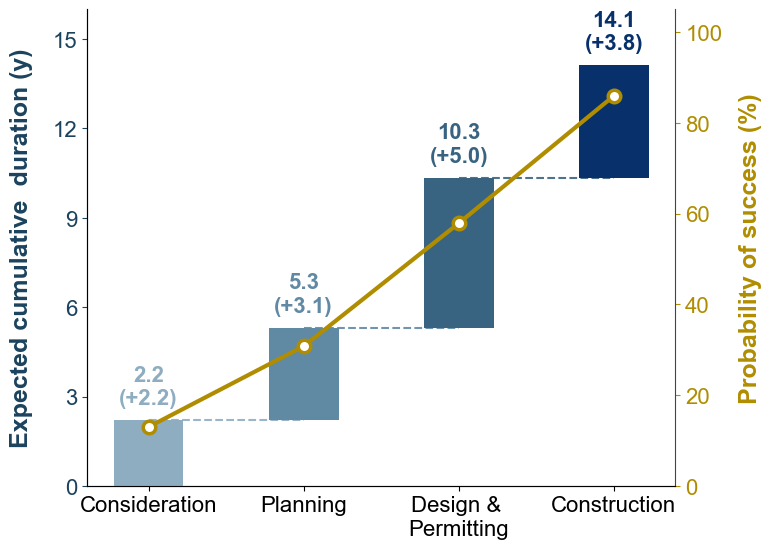

In [8]:
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['pdf.fonttype'] = 42

BASE_SIZE = 16 
mpl.rcParams['font.size'] = BASE_SIZE          
mpl.rcParams['axes.labelsize'] = 18            
mpl.rcParams['xtick.labelsize'] = 16           
mpl.rcParams['ytick.labelsize'] = 16           
mpl.rcParams['axes.labelweight'] = 'bold'      

states = ['Consideration', 'Planning', 'Design & \nPermitting', 'Construction']
mfpt_years = mfpt_to_5 
success_probs = prob_reach_5

durations = [mfpt_years[i] - mfpt_years[i+1] for i in range(len(mfpt_years)-1)] + [mfpt_years[-1]]
phase_durations = durations

starts = [0, phase_durations[0], sum(phase_durations[:2]), sum(phase_durations[:3])]

bar_colors = ['#8EADC1', '#6089A4', '#396481', '#08306B']
line_color = '#B08D00' 

fig, ax1 = plt.subplots(figsize=(8, 5.8)) 

bars = ax1.bar(states, phase_durations, bottom=starts, width=0.45, 
                color=bar_colors, edgecolor='none', zorder=3)

for i in range(len(starts) - 1):
    ax1.plot([i, i+1], [starts[i+1], starts[i+1]], color=bar_colors[i], 
              linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

ax1.set_ylabel('Expected cumulative  duration (y)', color='#1B435E', labelpad=14)
ax1.set_ylim(0, 16)
ax1.tick_params(axis='y', colors='#1B435E')
ax1.set_yticks(np.arange(0, 17, 3))

ax2 = ax1.twinx()
ax2.plot(states, success_probs, color=line_color, marker='o', markersize=9, 
         linewidth=3, markerfacecolor='white', markeredgewidth=2.5, zorder=4)

ax2.set_ylabel('Probability of success (%)', color=line_color, labelpad=12)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', colors=line_color)
ax2.set_yticks(np.arange(0, 1.01, 0.2))
ax2.set_yticklabels([f"{int(x*100)}" for x in ax2.get_yticks()])

for i, bar in enumerate(bars):
    y_top = starts[i] + phase_durations[i]
    stacked_label = f"{y_top:.1f}\n(+{phase_durations[i]:.1f})"
    
    ax1.text(bar.get_x() + bar.get_width() / 2, y_top + 0.4, stacked_label, 
             ha='center', va='bottom', color=bar_colors[i], weight='bold')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
spine_color = '#444444'
ax1.spines['bottom'].set_color(spine_color)
ax1.spines['left'].set_color(spine_color)
ax2.spines['right'].set_color(spine_color)

plt.tight_layout()
plt.savefig('Images/Waterfall_Duration.png', dpi=300, bbox_inches='tight')
plt.show()

#  FUNNEL COHORT - Robustness Check

In [9]:
PROJECT_COL = 'Inv_index' 

projects_starting_at_1 = df[df['Transition'] == '1 -> 2'][PROJECT_COL].unique()

df_funnel = df[df[PROJECT_COL].isin(projects_starting_at_1)].copy()

target_success = ['1 -> 2', '2 -> 3', '3 -> 4', '4 -> 5']

funnel_means = df_funnel.groupby('Transition')['Duration'].mean().reindex(target_success)
funnel_cumulative = funnel_means.cumsum()

funnel_counts = df_funnel.groupby('Transition').size().reindex(target_success).fillna(0).astype(int)

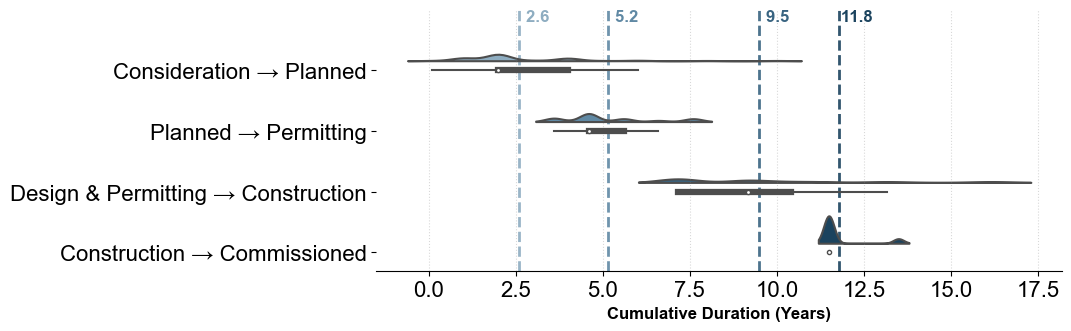

In [10]:

projects_starting_at_1 = df[df['Transition'] == '1 -> 2']['Inv_index'].unique()

df_funnel = df[df['Inv_index'].isin(projects_starting_at_1)].copy()

target_transitions = ['1 -> 2', '2 -> 3', '3 -> 4', '4 -> 5']
phase_mapping = {
    '1 -> 2': 'Consideration → Planned',
    '2 -> 3': 'Planned → Permitting',
    '3 -> 4': 'Design & Permitting → Construction',
    '4 -> 5': 'Construction → Commissioned'
}

df_subset = df_funnel[df_funnel['Transition'].isin(target_transitions)].copy()
df_shifted = df_subset.copy()
n_cat = len(target_transitions)

cumulative_shift = 0
start_points = {}
means = {} 

for trans in target_transitions:
    start_points[trans] = cumulative_shift
    mask = df_shifted['Transition'] == trans
    df_shifted.loc[mask, 'Duration'] += cumulative_shift
    
    mean_duration = df_subset[df_subset['Transition'] == trans]['Duration'].mean()
    means[trans] = mean_duration
    
    cumulative_shift += mean_duration

df_shifted['Transition'] = df_shifted['Transition'].map(phase_mapping)
order_labels = [phase_mapping[t] for t in target_transitions]

colors = ['#8EADC1', '#6089A4', '#396481', '#1B435E']

f, ax = plt.subplots(figsize=(11, 0.9 * n_cat))

pt.half_violinplot(
    data=df_shifted,
    x='Duration',
    y='Transition',
    order=order_labels, 
    palette=colors, 
    bw=0.2,
    ax=ax,
    orient='h',
    width=0.9
)

for i, trans in enumerate(target_transitions):
    start = start_points[trans]
    duration = means[trans]
    end_point = start + duration
    
    current_color = colors[i]
    
    ax.axvline(
        x=end_point, 
        color=current_color, 
        linestyle='--', 
        linewidth=2, 
        alpha=0.9,
        zorder=0
    )
    
    ax.text(end_point, -0.8, f'        {end_point:.1f}', 
            color=current_color, fontsize=12, ha='center', fontweight='bold', fontname="Arial")



plt.xlabel("Cumulative Duration (Years)", fontsize=12, fontname="Arial")

plt.grid(axis='x', linestyle=':', alpha=0.3, color='gray')
sns.despine(left=True)

plt.xticks(fontname="Arial")
plt.yticks(fontname="Arial")

ax.margins(y=0.2)
ax.set_ylim(n_cat - 0.7, -1) 

plt.tight_layout()
plt.savefig("Images/Raincloud_Duration_Funnel.png", dpi=300)
plt.show()

In [11]:
PROJECT_COL = 'Inv_index' 

projects_starting_at_2 = df[df['Transition'] == '2 -> 3'][PROJECT_COL].unique()

df_funnel_2 = df[df[PROJECT_COL].isin(projects_starting_at_2)].copy()

target_success = ['2 -> 3', '3 -> 4', '4 -> 5']

funnel_means = df_funnel_2.groupby('Transition')['Duration'].mean().reindex(target_success)
funnel_cumulative = funnel_means.cumsum()

funnel_counts = df_funnel_2.groupby('Transition').size().reindex(target_success).fillna(0).astype(int)


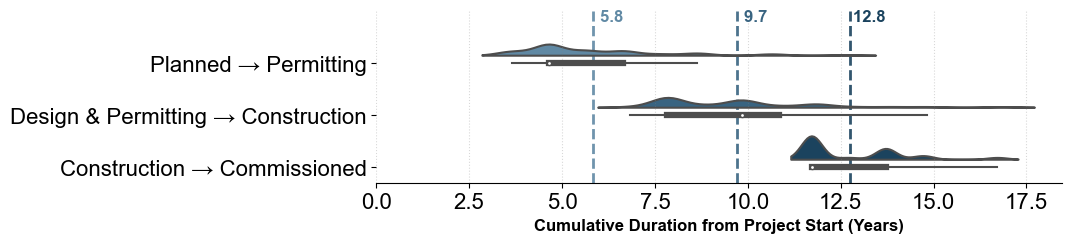

In [12]:
projects_starting_at_2 = df[df['Transition'] == '2 -> 3']['Inv_index'].unique()
df_funnel_2 = df[df['Inv_index'].isin(projects_starting_at_2)].copy()

target_transitions = ['2 -> 3', '3 -> 4', '4 -> 5']
phase_mapping = {
    '2 -> 3': 'Planned → Permitting',
    '3 -> 4': 'Design & Permitting → Construction',
    '4 -> 5': 'Construction → Commissioned'
}

df_subset = df_funnel_2[df_funnel_2['Transition'].isin(target_transitions)].copy()
df_shifted = df_subset.copy()
n_cat = len(target_transitions)

cumulative_shift = 2.64 
start_points = {}
means = {} 

for trans in target_transitions:
    start_points[trans] = cumulative_shift
    mask = df_shifted['Transition'] == trans
    df_shifted.loc[mask, 'Duration'] += cumulative_shift
    
    mean_duration = df_subset[df_subset['Transition'] == trans]['Duration'].mean()
    means[trans] = mean_duration
    cumulative_shift += mean_duration

df_shifted['Transition'] = df_shifted['Transition'].map(phase_mapping)
order_labels = [phase_mapping[t] for t in target_transitions]

colors = ['#6089A4', '#396481', '#1B435E']

f, ax = plt.subplots(figsize=(11, 0.9 * n_cat))

pt.half_violinplot(
    data=df_shifted,
    x='Duration',
    y='Transition',
    order=order_labels, 
    palette=colors, 
    bw=0.2,
    ax=ax,
    orient='h',
    width=0.9
)

for i, trans in enumerate(target_transitions):
    start = start_points[trans]
    duration = means[trans]
    end_point = start + duration
    current_color = colors[i]
    
    ax.axvline(x=end_point, color=current_color, linestyle='--', linewidth=2, alpha=0.9, zorder=0)
    
    ax.text(end_point, -0.8, f'        {end_point:.1f}', 
            color=current_color, fontsize=12, ha='center', fontweight='bold', fontname="Arial")

plt.xlabel("Cumulative Duration from Project Start (Years)", fontsize=12, fontname="Arial")

ax.set_xlim(0) 

plt.grid(axis='x', linestyle=':', alpha=0.3, color='gray')
sns.despine(left=True)
plt.xticks(fontname="Arial")
plt.yticks(fontname="Arial")
ax.margins(y=0.2)
ax.set_ylim(n_cat - 0.7, -1) 

plt.tight_layout()
plt.savefig("Images/Raincloud_Duration_Funnel_Phase2.png", dpi=300)
plt.show()